## Importing modules and libraries

In [13]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../src")

from eda import calculate_statistics, plot_distributions
from missing_data import MissingDataAnalyzer, visualize_missing_patterns, handle_missing_values
from preprocess import load_data, scale_data, inverse_scaler
from ts_trainer import create_sequences, time_series_cross_validate, plot_time_series_splits, plot_loss_fuction
from visualization import plot_time_series, plot_predictions_vs_actual

import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input
from keras.optimizers import Adam
from keras.metrics import RootMeanSquaredError, Mean
import numpy as np

plt.style.use('seaborn-v0_8')

## Load data

In [ ]:
df = load_data('../data/raw/Precipitation.csv')

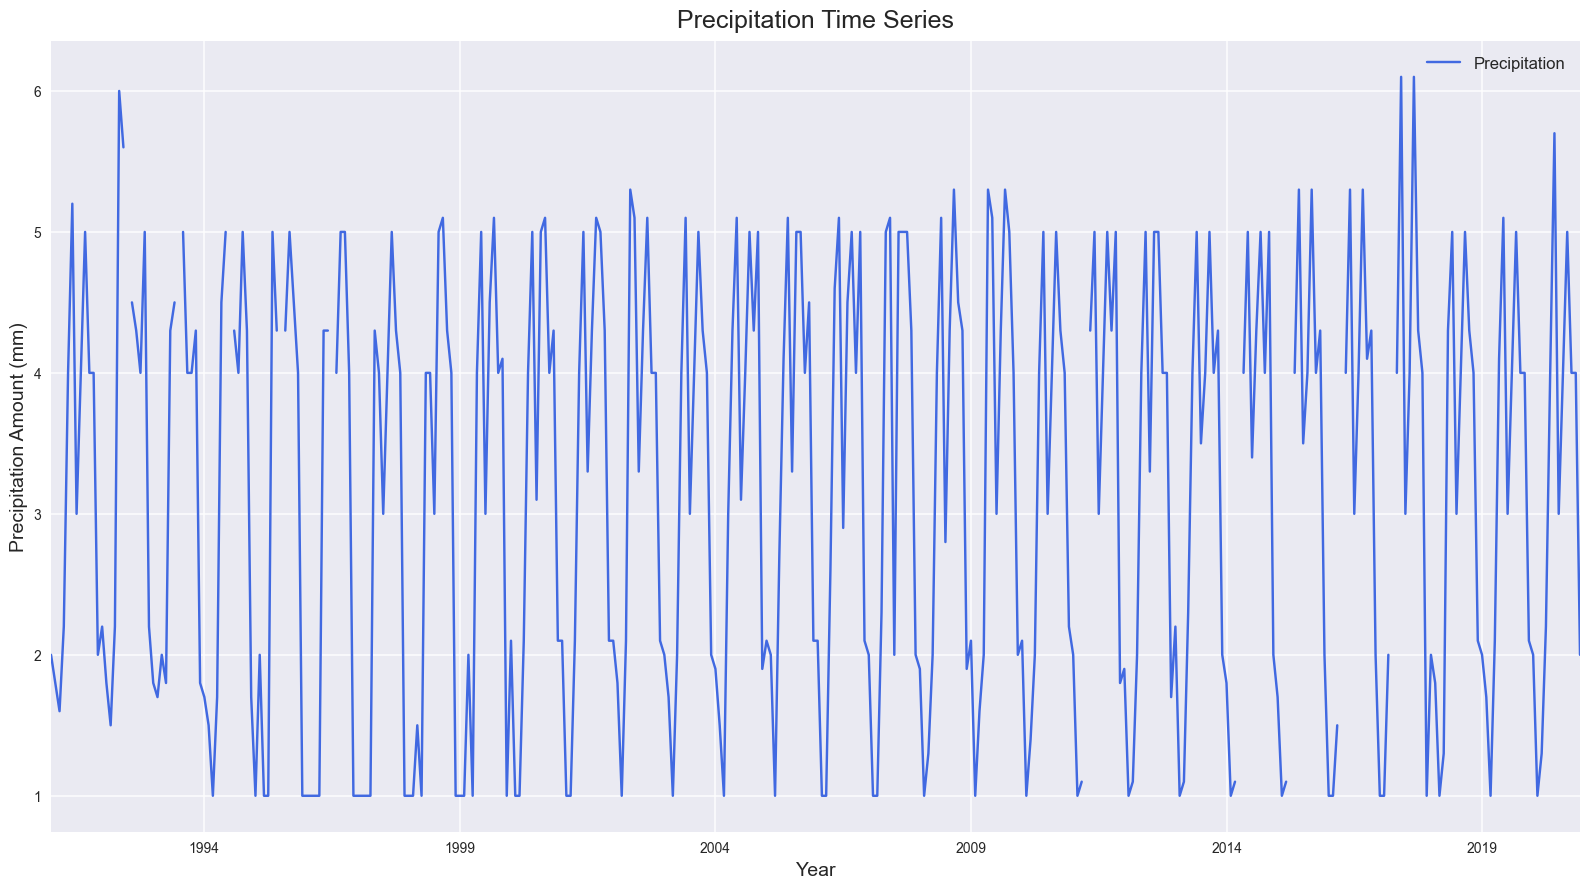

In [3]:
plot_time_series (
    df, 
    column='precipitation', 
    label='Precipitation',
    title='Precipitation Time Series',
    x_label='Year',
    y_label='Precipitation Amount (mm)')

## Exploratory Data Analysis

In [4]:
calculate_statistics (data=df, column='precipitation')

,Statistic,Value
0,Count,350.000
1,Minimum,1.000
2,Maximum,6.100
3,Mean,3.208
4,Median,4.000
5,Standard Deviation,1.502
6,Range,5.100
7,1st Quartile (Q1),1.900
8,3rd Quartile (Q3),4.300
9,Interquartile Range (IQR),2.400


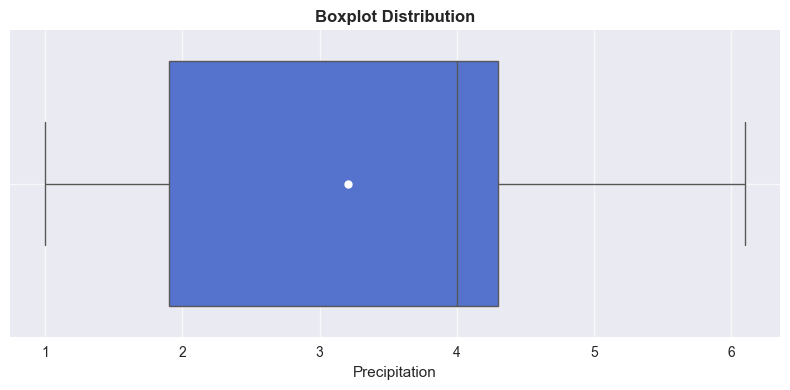

In [5]:
plot_distributions (df, column='precipitation', plot_type = 'boxplot')

### Missing Data Analysis

In [6]:
print(f"Missing Data: {df.missing.count_missing()}")
print(f"Present Data: {df.missing.count_complete()}")
df.missing.variable_summary()

Missing Data: 10
Present Data: 1430


,variable,n_missing,n_cases,pct_missing
2,precipitation,10,360,2.777778
0,year,0,360,0.000000
1,month_name,0,360,0.000000
3,month,0,360,0.000000


In [7]:
shadow_matrix = (
    df
    .missing
    .bind_shadow_matrix(only_missing_cols=True)
)

shadow_matrix.groupby(['precipitation_NA'])['month_name'].describe().reset_index()

,precipitation_NA,count,unique,top,freq
0,Missing,10,2,Jul,5
1,Present,350,12,Jan,30


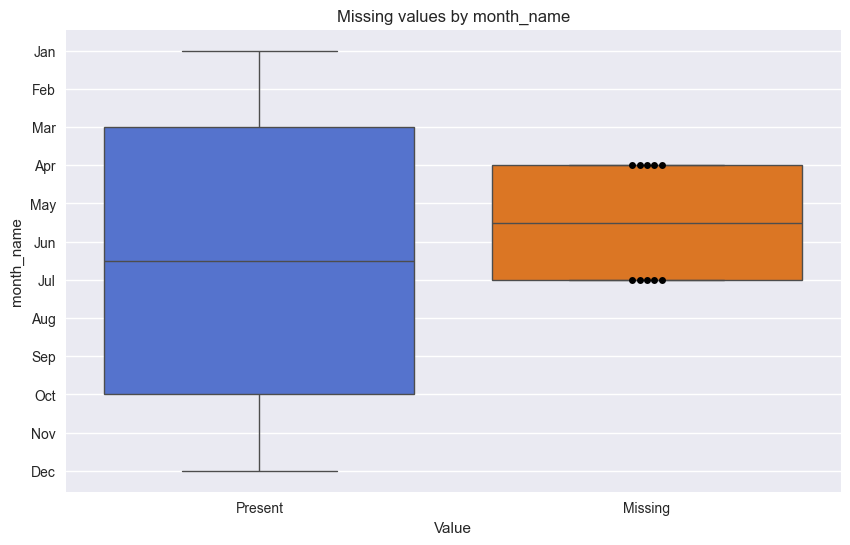

In [8]:
visualize_missing_patterns (df,'boxplot', x = 'month_name', value_col= 'precipitation')

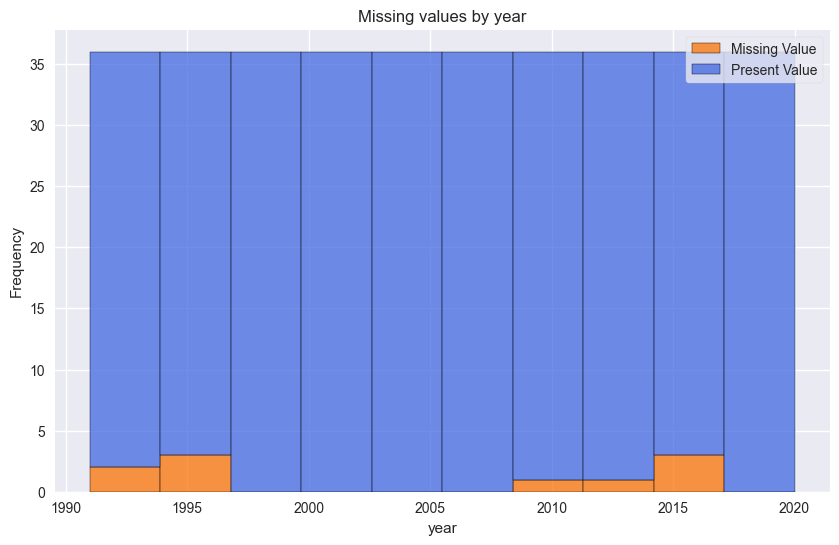

In [9]:
visualize_missing_patterns (df,'histplot', x = 'year', value_col= 'precipitation')

## Missing Data Handling

In [ ]:
df_complete = handle_missing_values(df,value_col='precipitation')

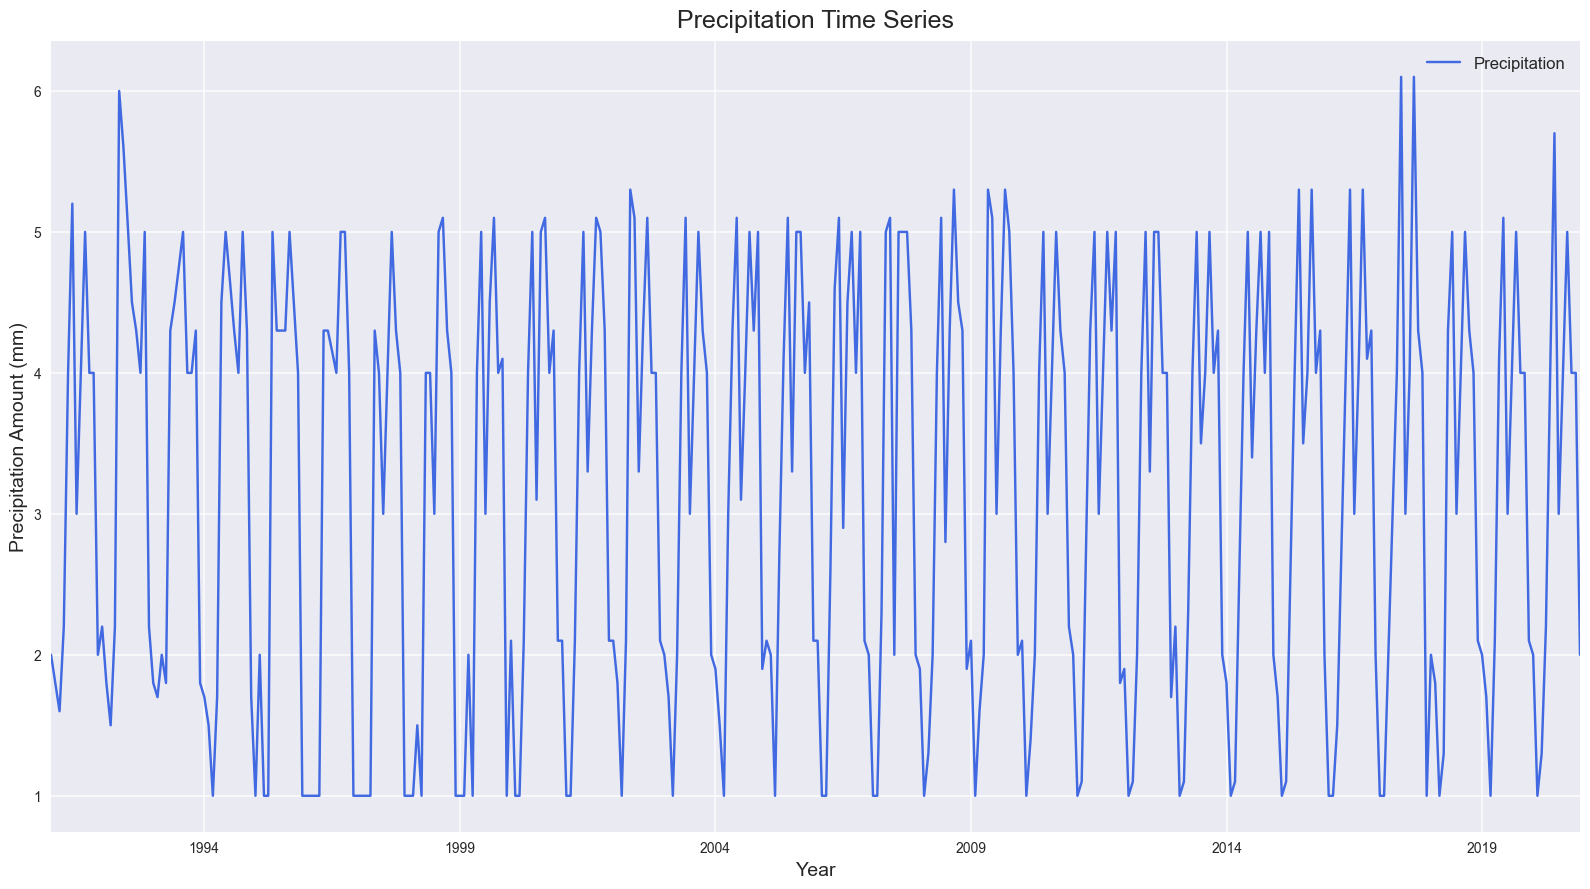

In [11]:
plot_time_series (
    df_complete, 
    column='precipitation', 
    label='Precipitation',
    title='Precipitation Time Series',
    x_label='Year',
    y_label='Precipitation Amount (mm)')

In [12]:
calculate_statistics (df_complete, column='precipitation')

,Statistic,Value
0,Count,360.000
1,Minimum,1.000
2,Maximum,6.100
3,Mean,3.220
4,Median,4.000
5,Standard Deviation,1.492
6,Range,5.100
7,1st Quartile (Q1),2.000
8,3rd Quartile (Q3),4.300
9,Interquartile Range (IQR),2.300


## Scaling

In [13]:
data = df_complete ['precipitation'].values.copy() 
index = df_complete.reset_index().index.to_numpy()

test_size = 48
Train_size = len(data)-test_size
val_size = 48 

test_data =  data[Train_size:] 
Train_data = data[:Train_size] 
test_index =  index[Train_size:] 
Train_index = index[:Train_size] 

In [ ]:
Train_data_scaled = scale_data (Train_data,test_data)[0]
test_data_scaled = scale_data (Train_data,test_data)[1]
scaler = scale_data (Train_data,test_data)[2]

['../outputs/models/scaler.pkl']

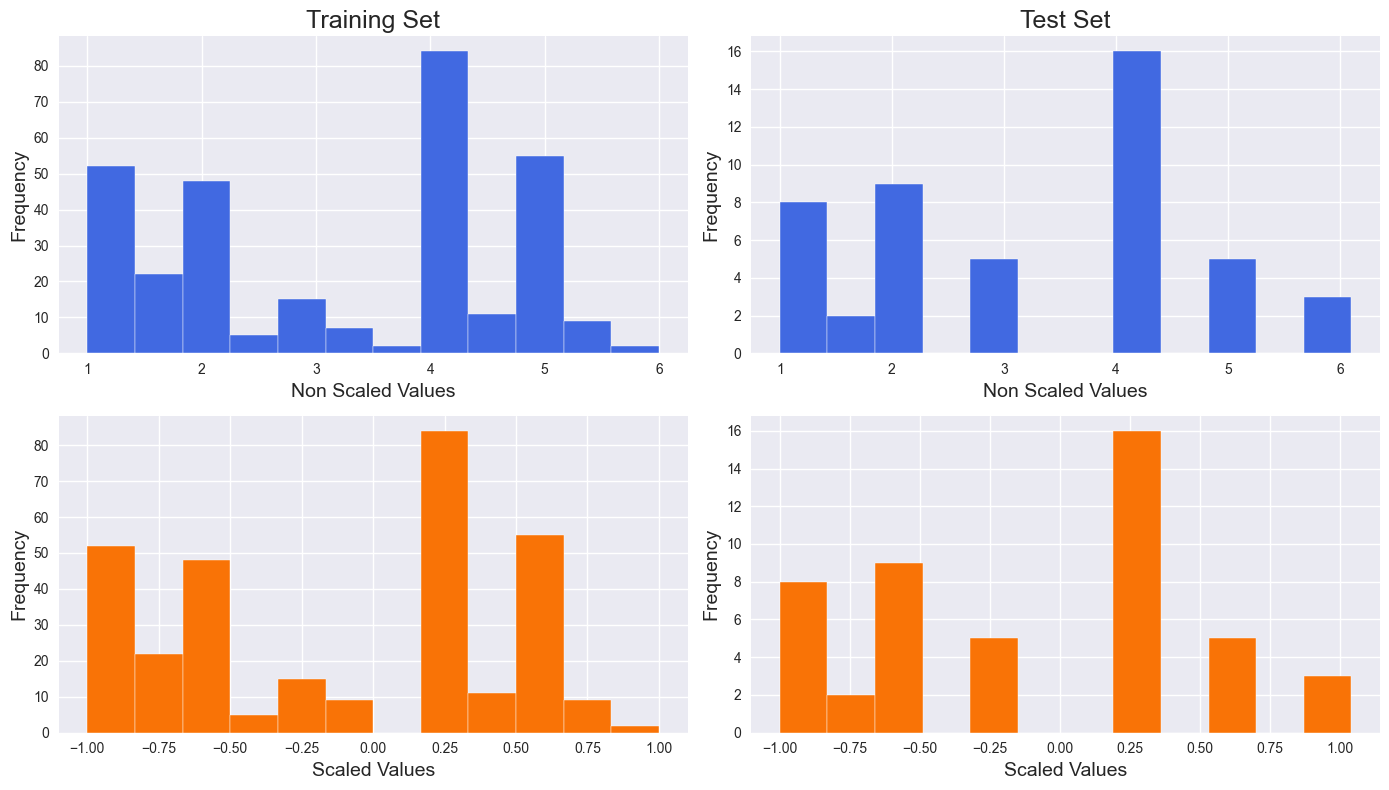

In [15]:
plt.figure(figsize=(14,8))
plt.subplot (2,2,1)
plt.hist(Train_data, bins=12, color = 'royalblue', edgecolor = 'white')
plt.title('Training Set', fontsize=18)
plt.xlabel('Non Scaled Values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.subplot (2,2,3)
plt.hist(Train_data_scaled, bins=12, color = '#F97306', edgecolor = 'white')
plt.xlabel('Scaled Values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.subplot (2,2,2)
plt.hist(test_data, bins=12, color = 'royalblue', edgecolor = 'white')
plt.title('Test Set', fontsize=18)
plt.xlabel('Non Scaled Values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.subplot (2,2,4)
plt.hist(test_data_scaled, bins=12, color = '#F97306', edgecolor = 'white')
plt.xlabel('Scaled Values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.tight_layout()

## Model Construction

In [16]:
input_length = 24 
output_length = 12

inputs = Input(shape=(input_length,1))
input_layer_out = LSTM (24,return_sequences=True)(inputs)
lstm_out_1 = LSTM(36)(input_layer_out)
outputs = Dense(12)(lstm_out_1)

model = Model(inputs=inputs, outputs=outputs)
model.compile (optimizer=Adam (learning_rate=0.0005), loss="mae",metrics=[RootMeanSquaredError])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 24)         │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 36)             │         8,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           444 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,724 (45.80 KB)

 Trainable params: 11,724 (45.80 KB)

 Non-trainable params: 0 (0.00 B)

## Model trainig

In [17]:
model_training = time_series_cross_validate(
    model = model, 
    data = Train_data_scaled, 
    index = Train_index, 
    input_length = 24, 
    output_length = 12, 
    n_splits = 4, 
    val_size = val_size, 
    batch_size = 36, 
    epochs = 500, 
    verbose = 0)


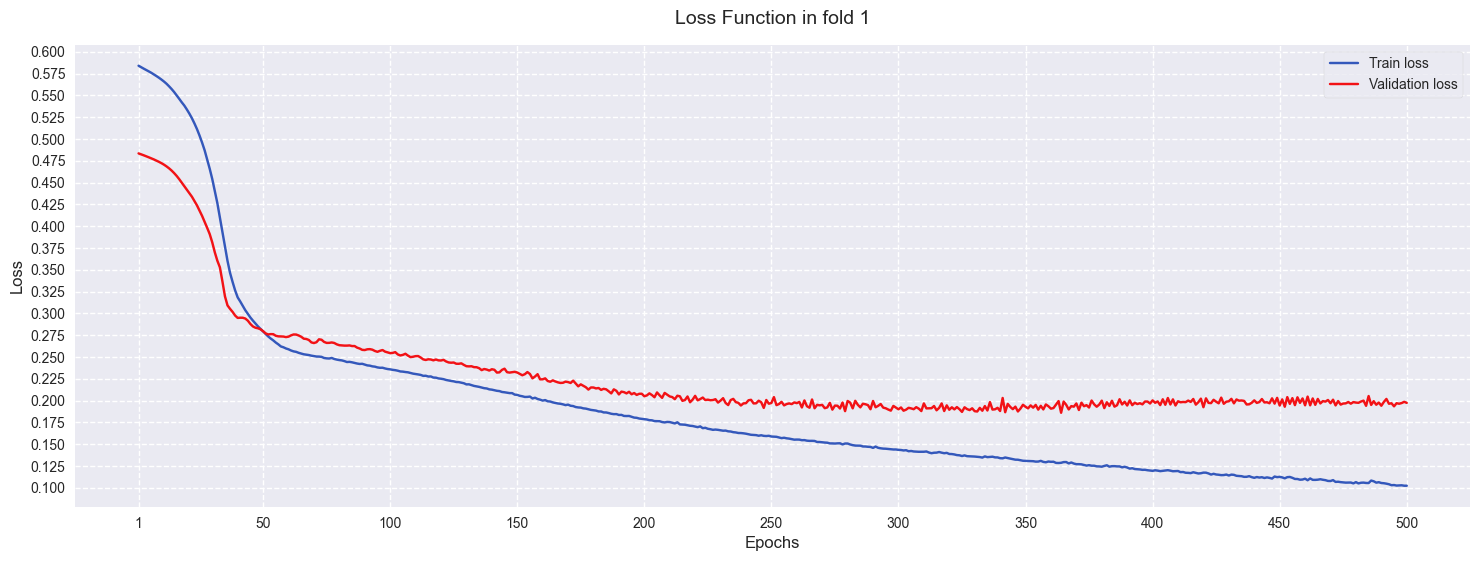

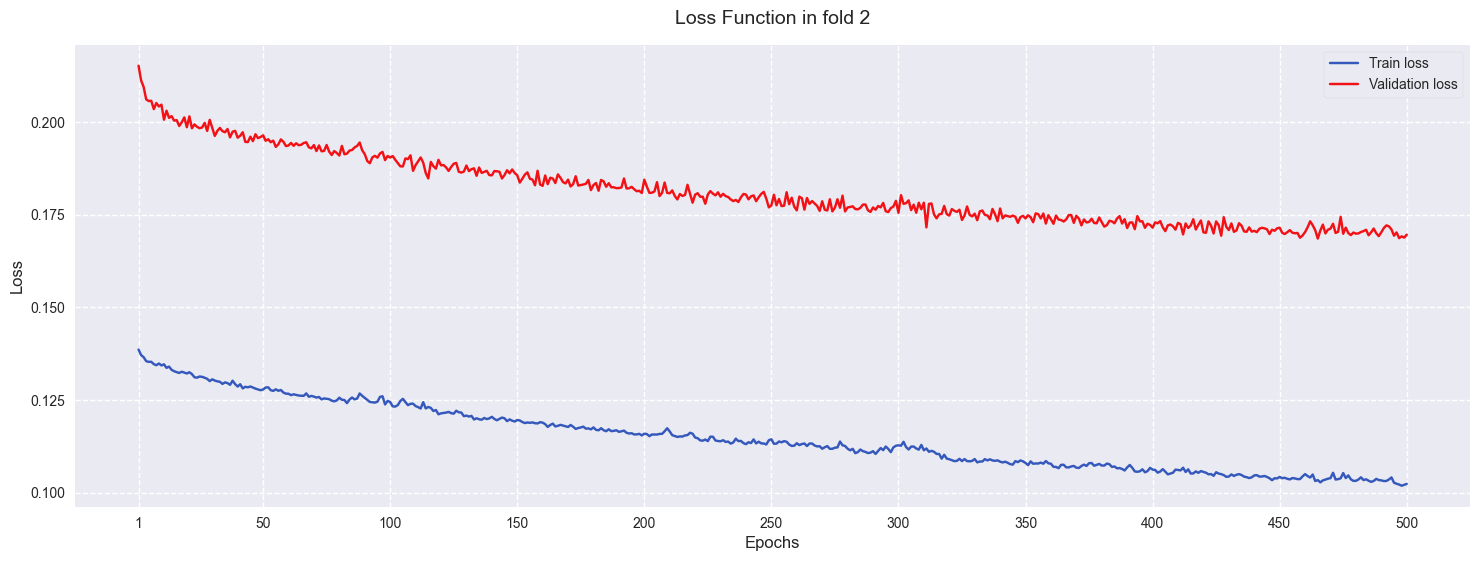

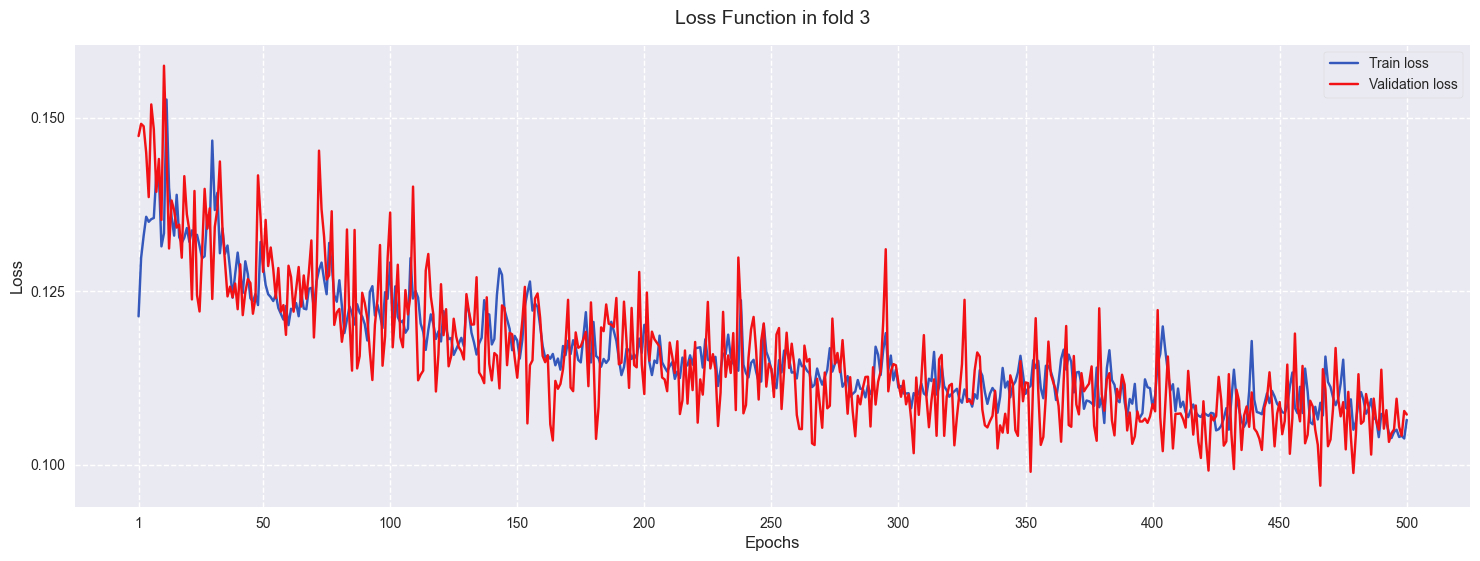

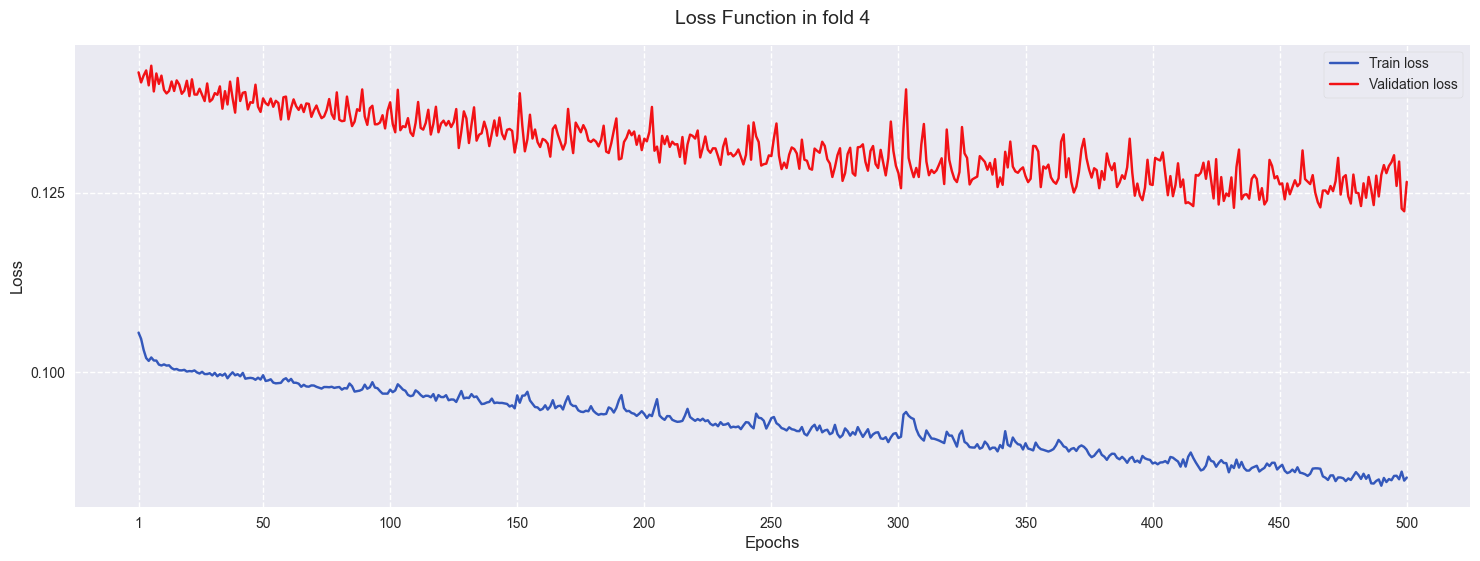

In [18]:
plot_loss_fuction (model_training[0],True)

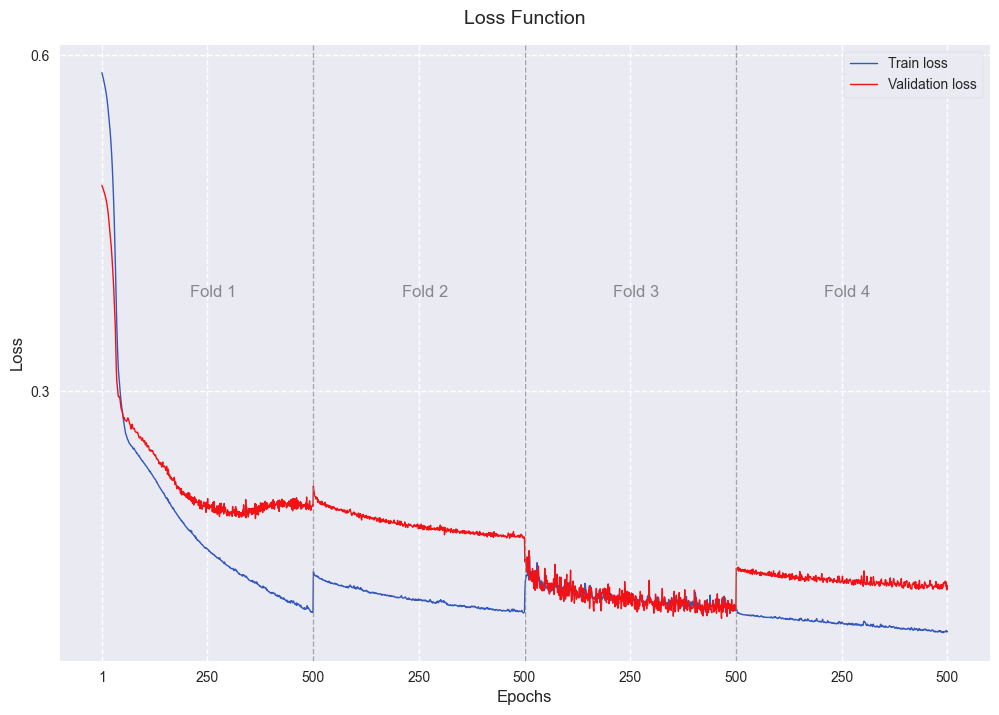

In [19]:
plot_loss_fuction (model_training[0],False)

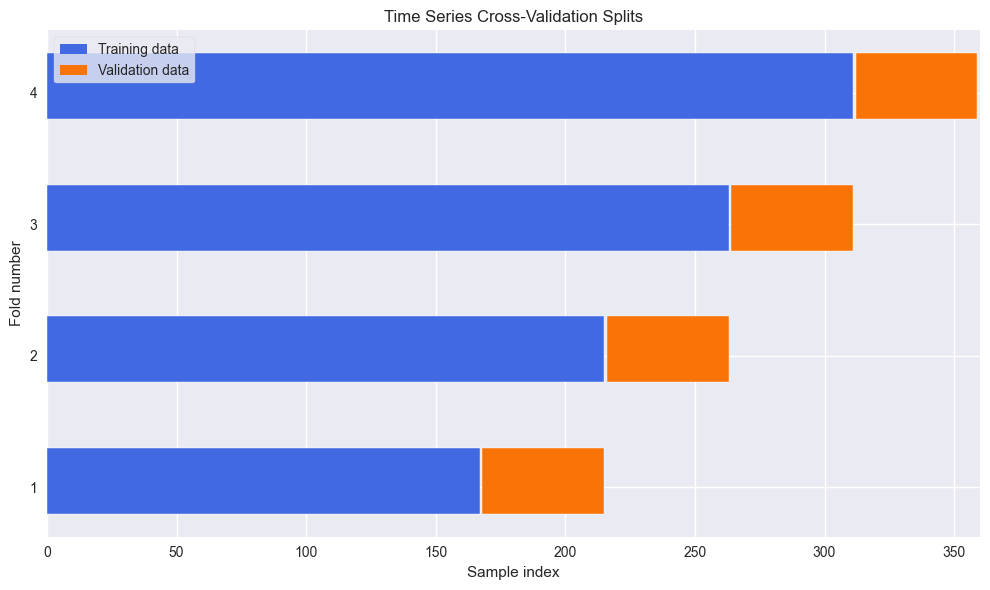

In [20]:
plot_time_series_splits(tscv = model_training[1], time_series_data = data)

## Model Prediction

In [21]:
x_test, y_test = create_sequences (test_data_scaled,input_length,output_length)
x_test = x_test.reshape(13,24)
y_test = y_test.reshape(13,12)

y_pred = model.predict(x_test,verbose=0)

predicted_values, actual_values = y_pred[len(y_pred)-1], y_test[len(y_pred)-1]

# Inverse scale
predicted_values, actual_values = inverse_scaler(scaler, predicted_values), inverse_scaler(scaler, actual_values)

## Model evaluation

In [22]:
# Model evaluation
test_history = model.evaluate(x_test,y_test,verbose=0)

# Calculate prediction bias
bias = np.mean (np.array(y_pred).flatten() - (y_test.flatten()))

# Evaluation in original scale
evaluation = test_history
evaluation.append(bias)
print (f'Evaluation in range [-1,1]: \nMAE: {evaluation[0]}\n RMSE: {evaluation[1]}\n bias {evaluation[2]}')
evaluation = inverse_scaler(scaler, evaluation, metrics=True)
print (f'\nEvaluation in original range: \nMAE: {evaluation[0]}\n RMSE: {evaluation[1]}\n bias {evaluation[2]}')

Evaluation in range [-1,1]: 
MAE: 0.10901597887277603
 RMSE: 0.13180507719516754
 bias 0.019054455682635307

Evaluation in original range: 
MAE: 0.2725399434566498
 RMSE: 0.32951268553733826
 bias 0.04763614013791084


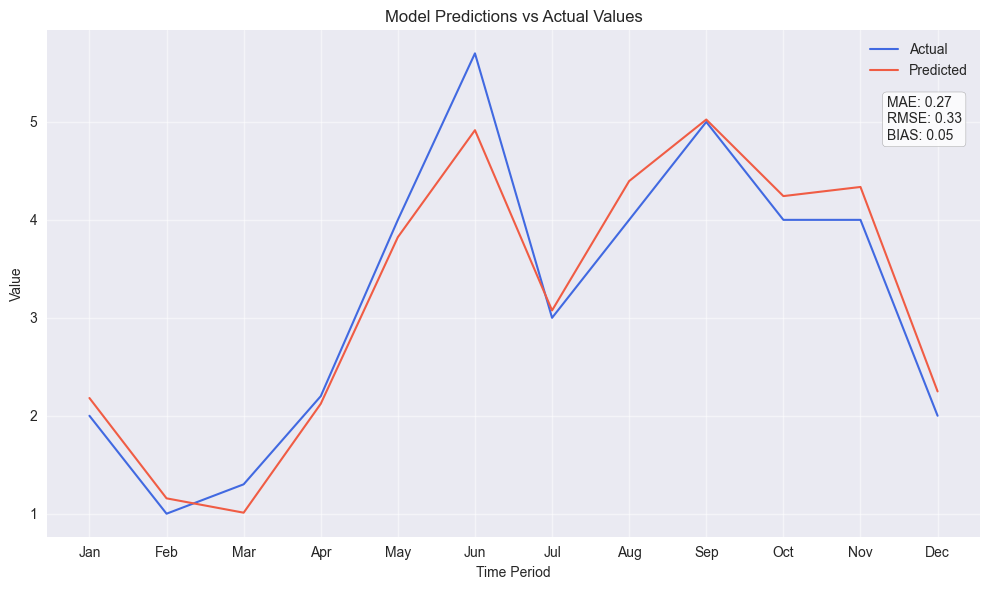

In [23]:
plot_predictions_vs_actual(actual_values=actual_values, predicted_values=predicted_values,
                              title='Model Predictions vs Actual Values',
                              x_label='Time Period',
                              y_label='Value',
                              metrics={'MAE':evaluation[0], 'RMSE':evaluation[1], 'BIAS': evaluation[2]},
                              x_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] )